<a href="https://colab.research.google.com/github/donna6355/study_python/blob/master/dl/RNN_%E1%84%89%E1%85%B5%E1%86%AF%E1%84%89%E1%85%B3%E1%86%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📖 RNN 첫걸음

> **🎯 이 노트북은 누구를 위한 건가요?**
> - "CNN은 들어봤는데, 시간이 흐르는 데이터는 어떻게 다루지?" 가 궁금한 분
> - 주가, 날씨, 한국어 문장 같은 **순서가 있는 데이터** 를 처리하고 싶은 분
> - 어려운 수식 없이 **그림과 비유로** 이해하고 싶은 분

---

## 📖 오늘의 이야기 한 줄 요약

> **"앞에서 본 걸 기억하면서 다음을 예측하는 신경망 — RNN."**

비유로 풀자면 — **한 줄씩 읽는 일기장** 같아요:

```
📖 일기 1줄째 읽음 → "흠, 오늘 비 왔구나"
📖 2줄째 읽음 → 1줄을 떠올리며 "비 와서 우산 잃어버렸군"
📖 3줄째 읽음 → 1, 2줄을 종합 → "우산 사러 가자고? 그렇겠네"
```

**한 글자씩, 한 단어씩, 한 시각씩** 보면서, 앞에서 봤던 정보를 **기억(hidden state)** 으로 다음 입력에 활용하는 게 RNN입니다.

## 🛠️ 준비물

| 항목 | 내용 |
|---|---|
| 환경 | Google Colab (무료) |
| 가속기 | CPU도 OK (GPU 있으면 더 빠름) |
| 시간 | 약 60~80분 |
| 사전 지식 | 파이썬 기본, PyTorch는 처음이어도 OK |

## 🗺️ 학습 로드맵

```
1️⃣ 시퀀스 데이터가 뭐야? CNN과 뭐가 달라?
2️⃣ RNN의 핵심 — Hidden State (기억 메모장 📝)
3️⃣ RNN 수식과 그림으로 이해
4️⃣ 환경 세팅 + 데이터 준비 (사인파 sin wave)
5️⃣ 🎯 미션 1: RNN cell forward 직접 만들기 ✏️
6️⃣ 직접 만든 RNN으로 시퀀스 처리
7️⃣ PyTorch nn.RNN — 한 줄로!
8️⃣ 학습 + 예측 시각화 ⭐
9️⃣ 🎯 미션 2: 시퀀스 길이별 정확도 분석 ✏️
🔟 RNN의 한계 + LSTM 예고
1️⃣1️⃣ 도전 과제
```

> **💡 학습 팁**: 미션 1에서 **RNN의 forward 한 step을 직접 손으로 짜본다** — 이게 RNN을 진짜 이해하는 핵심이에요. 답 보지 말고 2~3분 고민!


---
# 1️⃣ 시퀀스 데이터 — 왜 RNN이 필요한가?

## 1.1 [비유로 이해] 사진 한 장 vs 영상 한 편

CNN은 **사진 한 장** 처리에 특화돼 있어요. 픽셀 사이 위치 관계만 봅니다.
근데 영상은 어떻게 처리할까요? 사진 100장을 따로따로 보면 — 흐름을 놓쳐요.

```
📷 사진 한 장   = 위치 정보만 (CNN으로 충분)
🎬 영상 / 음성 / 텍스트 = 시간 흐름 (순서 정보 필수!)
```

## 1.2 시퀀스 데이터 예시

| 종류 | 예시 | 순서가 중요한 이유 |
|---|---|---|
| **텍스트** | "나는 학교에 갔다" | 단어 순서 바꾸면 의미 바뀜 ("학교에 나는 갔다" 어색) |
| **음성** | 0.01초마다 음파 진폭 | 순서가 곧 소리 |
| **주가** | 매일의 종가 | 어제 → 오늘의 흐름이 핵심 |
| **날씨** | 매시간 기온 | 오늘 흐림 → 내일 비 가능성 ↑ |
| **공정 센서** | 1초마다 온도/압력 | 추세 변화가 결함 신호 |
| **DNA** | A-T-G-C 염기서열 | 순서 자체가 정보 |

## 1.3 [중요] 단순한 신경망은 왜 안 될까?

**MLP (Multi-Layer Perceptron)** 으로 시퀀스를 처리하려면:

```
입력: [어제 기온, 오늘 기온, 내일 기온?]
                                    └ 빈칸: 예측 대상
```

MLP는 입력 길이가 **고정** 이어야 해요. 5일치만 보고 싶을 때는 MLP를 새로 만들어야 함.
또 MLP는 **입력 위치를 구별 못 해요** — 5일치든 10일치든, 모든 입력을 동등하게 봅니다.

> **시퀀스의 본질은 "앞 데이터가 뒤 데이터에 영향을 준다"**
> → 이걸 자연스럽게 모델링하려면? **순환 (Recurrent)** 구조가 필요!

## 1.4 RNN의 직관: "기억을 가진 신경망"

```
시각 1: 입력 받고 → 처리 → 결과 + 📝 기억 저장
시각 2: 입력 + 📝 기억 → 처리 → 결과 + 📝 기억 갱신
시각 3: 입력 + 📝 기억 → 처리 → 결과 + 📝 기억 갱신
...
```

이 **📝 기억** 이 RNN의 **hidden state** 입니다. 다음 셀에서 그림으로 봅시다.


In [1]:
# 한글 폰트
!apt-get install -y fonts-nanum > /dev/null
!fc-cache -fv > /dev/null

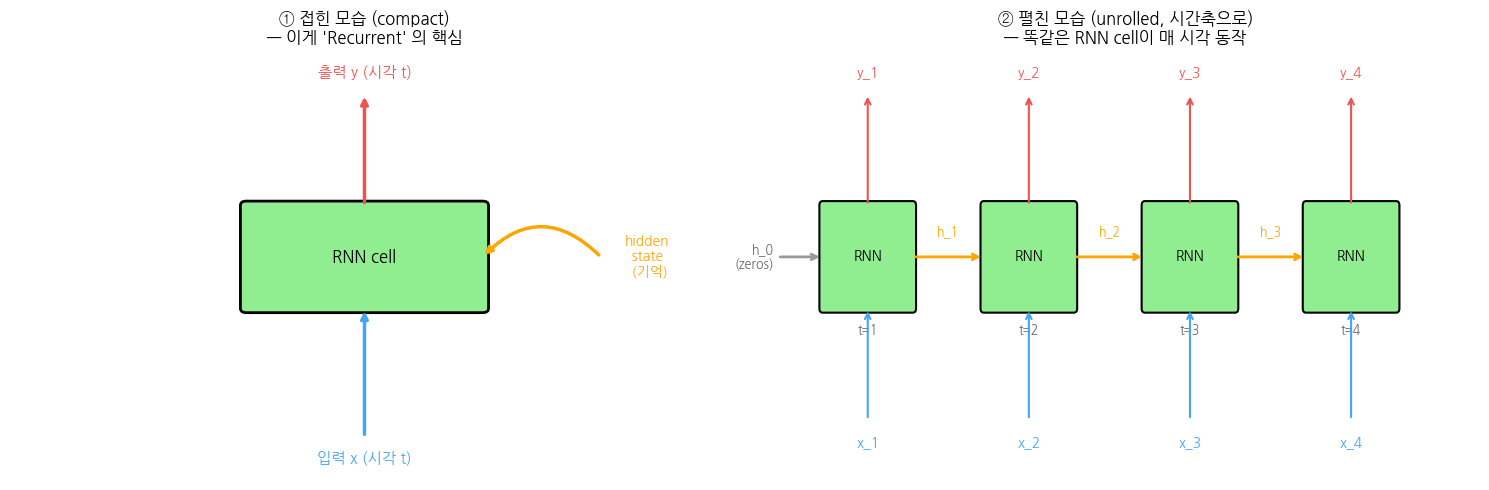


💡 핵심 포인트:
  - 같은 RNN cell이 시각마다 반복 적용됨 (그래서 '순환 Recurrent')
  - 시각 t의 hidden state h_t가 → 시각 t+1로 전달 = 기억 전수
  - W (가중치) 는 모든 시각에 공유! 시간이 길어도 파라미터 수는 안 늘어요


In [2]:
# 🖼️ RNN 시각화 — 두 가지 그림 (접힌 모습 vs 펼친 모습)

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.font_manager as fm
import numpy as np
import os

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── 왼쪽: 접힌 모습 (compact view) ──
ax = axes[0]
ax.set_xlim(0, 6); ax.set_ylim(0, 5)
ax.axis("off")
ax.set_title("① 접힌 모습 (compact)\n— 이게 'Recurrent' 의 핵심", fontsize=12)

# RNN 박스
ax.add_patch(patches.FancyBboxPatch((2, 2), 2, 1.2,
    boxstyle="round,pad=0.05", facecolor="#90EE90", edgecolor="black", lw=2))
ax.text(3, 2.6, "RNN cell", ha="center", va="center", fontsize=12, fontweight="bold")

# 입력 화살표 (아래에서 위로)
ax.annotate("", xy=(3, 2), xytext=(3, 0.5),
            arrowprops=dict(arrowstyle="->", lw=2.5, color="#42a5f5"))
ax.text(3, 0.2, "입력 x (시각 t)", ha="center", fontsize=11, color="#42a5f5")

# 출력 화살표
ax.annotate("", xy=(3, 4.5), xytext=(3, 3.2),
            arrowprops=dict(arrowstyle="->", lw=2.5, color="#ef5350"))
ax.text(3, 4.7, "출력 y (시각 t)", ha="center", fontsize=11, color="#ef5350")

# 자기 자신으로 가는 화살표 (recurrent edge!)
ax.annotate("", xy=(4, 2.6), xytext=(5, 2.6),
            arrowprops=dict(arrowstyle="->", lw=2.5,
                            color="#FFA500",
                            connectionstyle="arc3,rad=0.5"))
ax.text(5.2, 2.6, "hidden\n  state\n  (기억)",
        ha="left", va="center", fontsize=10, color="#FFA500", fontweight="bold")

# ── 오른쪽: 펼친 모습 (unrolled) ──
ax = axes[1]
ax.set_xlim(0, 11); ax.set_ylim(0, 5)
ax.axis("off")
ax.set_title("② 펼친 모습 (unrolled, 시간축으로)\n— 똑같은 RNN cell이 매 시각 동작",
             fontsize=12)

# 4개 timestep
for i, t in enumerate(["t=1", "t=2", "t=3", "t=4"]):
    x_center = 1.5 + i * 2.5
    # RNN 박스
    ax.add_patch(patches.FancyBboxPatch((x_center - 0.7, 2), 1.4, 1.2,
        boxstyle="round,pad=0.05", facecolor="#90EE90", edgecolor="black", lw=1.5))
    ax.text(x_center, 2.6, "RNN", ha="center", va="center", fontsize=10)
    ax.text(x_center, 1.7, t, ha="center", fontsize=9, color="#666")

    # 입력 화살표
    ax.annotate("", xy=(x_center, 2), xytext=(x_center, 0.7),
                arrowprops=dict(arrowstyle="->", lw=1.5, color="#42a5f5"))
    ax.text(x_center, 0.4, f"x_{i+1}", ha="center", fontsize=10, color="#42a5f5")

    # 출력 화살표
    ax.annotate("", xy=(x_center, 4.5), xytext=(x_center, 3.2),
                arrowprops=dict(arrowstyle="->", lw=1.5, color="#ef5350"))
    ax.text(x_center, 4.7, f"y_{i+1}", ha="center", fontsize=10, color="#ef5350")

    # 가로 (recurrent) 화살표
    if i < 3:
        x_next = 1.5 + (i + 1) * 2.5
        ax.annotate("", xy=(x_next - 0.7, 2.6), xytext=(x_center + 0.7, 2.6),
                    arrowprops=dict(arrowstyle="->", lw=2, color="#FFA500"))
        ax.text((x_center + x_next)/2, 2.85, f"h_{i+1}", ha="center",
                fontsize=9, color="#FFA500", fontweight="bold")

# 초기 hidden state
ax.annotate("", xy=(0.8, 2.6), xytext=(0.1, 2.6),
            arrowprops=dict(arrowstyle="->", lw=2, color="#999"))
ax.text(0.05, 2.6, "h_0\n(zeros)", ha="right", va="center",
        fontsize=9, color="#666")

plt.tight_layout()
plt.show()

print("\n💡 핵심 포인트:")
print("  - 같은 RNN cell이 시각마다 반복 적용됨 (그래서 '순환 Recurrent')")
print("  - 시각 t의 hidden state h_t가 → 시각 t+1로 전달 = 기억 전수")
print("  - W (가중치) 는 모든 시각에 공유! 시간이 길어도 파라미터 수는 안 늘어요")

---
# 2️⃣ Hidden State — RNN의 심장

## 2.1 [비유로 이해] 메모장에 적어가며 책 읽기 📝

긴 책을 읽을 때, 한 페이지를 넘기면 앞 내용을 다 잊어버리지는 않죠?
**중요한 내용을 메모장에 적어두고**, 다음 페이지를 읽을 때 메모를 참고합니다.

```
📖 1페이지: "주인공이 학교 갔다"
📝 메모: "학교"

📖 2페이지: "친구를 만났다"
📝 메모 갱신: "학교, 친구 만남"

📖 3페이지: "둘이 도서관에 갔다"
📝 메모 갱신: "학교 → 친구 → 도서관"
```

이 **📝 메모장이 hidden state** 입니다.
- 매 시각 갱신됨 (페이지 넘길 때마다)
- 다음 시각의 처리에 영향을 줌
- **무한히 늘어나지 않음** (메모장 크기는 정해져 있음 — hidden_size)

## 2.2 RNN의 한 줄 수식

> **h_t = tanh(W_xh · x_t + W_hh · h_{t-1} + b)**

겁먹지 말고, 한 부분씩 풀어보면:

| 부분 | 의미 | 메모장 비유 |
|---|---|---|
| `x_t` | 시각 t의 입력 | "방금 읽은 페이지" |
| `h_{t-1}` | 직전 시각의 hidden state | "전 페이지까지의 메모" |
| `W_xh · x_t` | 입력에 가중치 곱 | "이번 페이지에서 뭘 적을지" |
| `W_hh · h_{t-1}` | 직전 메모에 가중치 곱 | "전 메모를 어떻게 다듬을지" |
| `+ b` | 편향 (보조 항) | (사소한 조정) |
| `tanh(...)` | -1~1 사이로 압축 | "메모가 너무 길어지지 않게 정리" |
| `h_t` | 새 hidden state | "갱신된 메모장" |

> 💡 **핵심**: `h_t` 는 **이번 입력 + 이전 메모** 의 조합입니다. 그래서 RNN이 시퀀스의 흐름을 따라가요.

## 2.3 출력 y는?

hidden state `h_t` 자체를 출력으로 쓰거나, 한 번 더 변환해서:

> **y_t = W_hy · h_t + b_y**

또는 분류 문제면 `softmax(W_hy · h_t)` 로 확률을 만듭니다.

## 2.4 [중요] 가중치 공유

RNN의 W_xh, W_hh, W_hy는 **모든 시각에 동일한 값** 을 씁니다.

```
시각 1, 2, 3, ..., 100: 같은 W로 처리!
```

이 덕분에:
- ✅ 시퀀스 길이가 달라도 같은 모델 사용 가능
- ✅ 파라미터 수가 입력 길이에 무관 (일반화에 좋음)
- ❌ 단점: 너무 긴 시퀀스에서 정보가 희석됨 (vanishing gradient — LSTM에서 다룸)


---
# 3️⃣ 환경 세팅 + 데이터 준비

PyTorch는 Colab에 미리 설치돼 있어 추가 설치는 한글 폰트 정도만 필요해요.


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os, sys

# 한글 폰트 등록
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# 시드 고정
torch.manual_seed(42); np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Python   : {sys.version.split()[0]}")
print(f"PyTorch  : {torch.__version__}")
print(f"디바이스 : {device}")
print("✅ 환경 준비 완료")

Python   : 3.12.13
PyTorch  : 2.10.0+cu128
디바이스 : cuda
✅ 환경 준비 완료


## 3.1 데이터 준비 — 사인파(Sine Wave) 예측

오늘 다룰 task: **앞 N개 값을 보고 다음 1개 값 예측하기**

> 💡 **왜 사인파?**
> - 패턴이 명확해 학습 효과 직관적으로 보임
> - 노이즈 추가하면 실제 시계열 데이터(주가, 센서값) 과 유사
> - 시각화가 깔끔


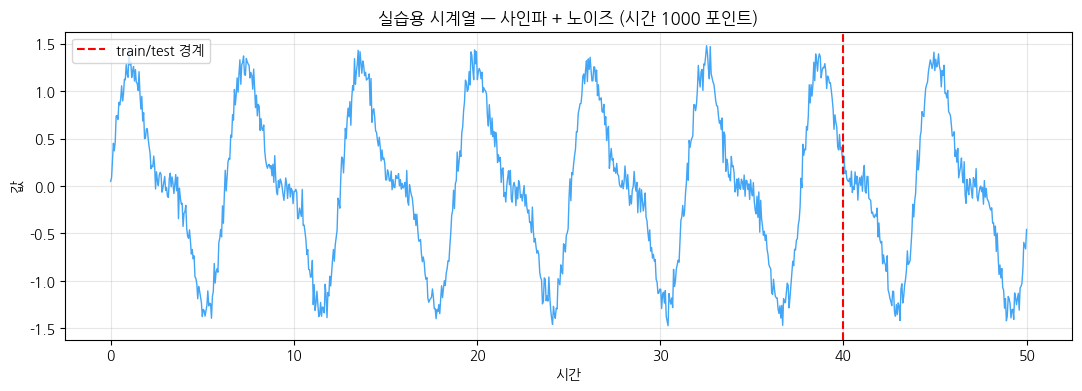

데이터 길이: 1000
평균 0.00, 표준편차 0.80


In [4]:
# 사인파 + 약간의 노이즈 — 1000 시점
N = 1000
t = np.linspace(0, 50, N)
signal = np.sin(t) + 0.5 * np.sin(2 * t) + 0.1 * np.random.randn(N)

plt.figure(figsize=(13, 4))
plt.plot(t, signal, lw=1, color="#42a5f5")
plt.axvline(40, color="red", ls="--", label="train/test 경계")
plt.title("실습용 시계열 — 사인파 + 노이즈 (시간 1000 포인트)")
plt.xlabel("시간"); plt.ylabel("값")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

print(f"데이터 길이: {N}")
print(f"평균 {signal.mean():.2f}, 표준편차 {signal.std():.2f}")

## 3.2 [중요] 슬라이딩 윈도우 — 시퀀스로 자르기

긴 시계열을 RNN에게 주려면 **(입력 시퀀스, 정답)** 쌍으로 잘라야 해요.

```
시점:  0  1  2  3  4  5  6  7  8  9 ...
값  :  v0 v1 v2 v3 v4 v5 v6 v7 v8 v9 ...

윈도우 크기 5로 슬라이딩 자르기:
샘플 1: 입력 [v0 v1 v2 v3 v4] → 정답 v5
샘플 2: 입력 [v1 v2 v3 v4 v5] → 정답 v6
샘플 3: 입력 [v2 v3 v4 v5 v6] → 정답 v7
...
```

비유: **"마지막 5문제 본 시험" → 다음 한 문제 예측**


In [5]:
def make_sequences(data, window_size=20):
    """슬라이딩 윈도우로 시퀀스 데이터셋 만들기."""
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size])      # 입력: 길이 window_size
        y.append(data[i + window_size])          # 정답: 그 다음 1개
    return np.array(X), np.array(y)


WINDOW = 20  # 마지막 20개 값으로 다음 값 예측

# train/test 분리
train_signal = signal[:800]
test_signal  = signal[800:]

X_train, y_train = make_sequences(train_signal, WINDOW)
X_test,  y_test  = make_sequences(test_signal,  WINDOW)

print(f"X_train.shape = {X_train.shape}  → ({X_train.shape[0]}개 샘플, "
      f"각 샘플 길이 {WINDOW})")
print(f"y_train.shape = {y_train.shape}")
print(f"X_test.shape  = {X_test.shape}")

# 첫 샘플 보기
print(f"\n첫 샘플의 입력 (길이 {WINDOW}): {X_train[0][:5].round(3)} ... {X_train[0][-3:].round(3)}")
print(f"첫 샘플의 정답: {y_train[0]:.3f}")

# PyTorch 텐서로 변환 — RNN은 (batch, seq_len, features) 형태 입력
X_train_t = torch.FloatTensor(X_train).unsqueeze(-1)   # (N, 20, 1)
y_train_t = torch.FloatTensor(y_train).unsqueeze(-1)   # (N, 1)
X_test_t  = torch.FloatTensor(X_test).unsqueeze(-1)
y_test_t  = torch.FloatTensor(y_test).unsqueeze(-1)
print(f"\nPyTorch 형식: X_train_t.shape = {X_train_t.shape}")
print(f"  → (배치 크기, 시퀀스 길이, feature 차원)")

X_train.shape = (780, 20)  → (780개 샘플, 각 샘플 길이 20)
y_train.shape = (780,)
X_test.shape  = (180, 20)

첫 샘플의 입력 (길이 20): [0.05  0.086 0.264 0.45  0.37 ] ... [1.279 1.18  1.146]
첫 샘플의 정답: 1.443

PyTorch 형식: X_train_t.shape = torch.Size([780, 20, 1])
  → (배치 크기, 시퀀스 길이, feature 차원)


---
# 4️⃣ 🎯 미션 1: RNN cell의 한 step forward 직접 만들기 ✏️

위 수식 `h_t = tanh(W_xh · x_t + W_hh · h_{t-1} + b)` 를 직접 코드로 옮겨봅시다.
**한 시각의 forward만** 짜는 거라 어렵지 않아요.

> **⏰ 3분 도전!** 위 2.2절 표를 다시 보면 답이 보일 거예요.
> 빈칸 4개입니다.

## 4.1 PyTorch 행렬 곱 quick reminder

```python
A @ B           # 행렬 곱 (numpy의 np.dot과 같음)
torch.tanh(x)   # 원소별 tanh, -1~1 사이로 압축
```


In [8]:
# 🎯 미션 1: RNN cell의 한 step forward

def rnn_cell_step(x_t, h_prev, W_xh, W_hh, b):
    """
    RNN cell의 한 시각 forward pass.

    인자:
        x_t    : (input_size,)        — 시각 t의 입력
        h_prev : (hidden_size,)        — 직전 시각의 hidden state (h_{t-1})
        W_xh   : (input_size, hidden_size)   — 입력 → hidden 가중치
        W_hh   : (hidden_size, hidden_size)  — hidden → hidden 가중치
        b      : (hidden_size,)              — 편향
    반환:
        h_t : (hidden_size,) — 새 hidden state
    """
    # ── Step 1: 입력에 가중치 곱 ──
    # 💡 힌트: x_t @ W_xh  (행렬 곱)
    z_input = x_t @ W_xh                   # ✏️ x_t와 W_xh 곱하기

    # ── Step 2: 직전 hidden state에 가중치 곱 ──
    # 💡 힌트: h_prev @ W_hh
    z_hidden = h_prev @ W_hh                   # ✏️ h_prev와 W_hh 곱하기

    # ── Step 3: 두 결과 + 편향 합치기 ──
    z_total = z_input + z_hidden + b    # ✏️ 편향 b 더하기

    # ── Step 4: tanh 활성화로 -1~1 압축 ──
    # 💡 힌트: torch.tanh()
    h_t = torch.tanh(z_total)              # ✏️ tanh

    return h_t


print("✏️ 빈칸 다 채우셨나요? 다음 검증 셀로 가보세요.")

✏️ 빈칸 다 채우셨나요? 다음 검증 셀로 가보세요.


<details>
<summary>🔑 정답 보기 (먼저 직접 풀어보세요!)</summary>

```python
z_input = x_t @ W_xh
z_hidden = h_prev @ W_hh
z_total = z_input + z_hidden + b
h_t = torch.tanh(z_total)
```

**한 줄 요약**: 입력 가중합 + 직전 메모 가중합 + 편향 → tanh로 압축.

**왜 tanh?**
- 출력 범위가 -1~1 → 값이 폭발적으로 커지는 걸 막음
- 음수도 표현 가능 (시그모이드는 0~1)
- 0 근처에서 거의 선형 → 학습이 안정적

</details>

## 4.2 미션 1 검증 — 한 step 동작 확인


In [9]:
# 🧪 미션 1 검증

# 작은 차원으로 실험 (input=1, hidden=4)
input_size = 1
hidden_size = 4

# 가중치 초기화 (보통 작은 랜덤값)
torch.manual_seed(0)
W_xh = torch.randn(input_size, hidden_size) * 0.1
W_hh = torch.randn(hidden_size, hidden_size) * 0.1
b = torch.zeros(hidden_size)

# 시각 1 입력 + 초기 hidden state (zeros)
x_1 = torch.tensor([0.5])
h_0 = torch.zeros(hidden_size)

h_1 = rnn_cell_step(x_1, h_0, W_xh, W_hh, b)
print(f"입력 x_1     : {x_1.tolist()}")
print(f"초기 h_0     : {h_0.tolist()}")
print(f"새 hidden h_1: {h_1.tolist()}")

# 검증: shape이 맞는지
assert h_1.shape == (hidden_size,), f"shape 오류: {h_1.shape}"
# 검증: tanh 적용으로 -1~1 사이 값
assert h_1.abs().max() <= 1.0, f"tanh 안 적용됨: max abs = {h_1.abs().max()}"
# 검증: 입력이 0이 아니면 hidden도 변해야 함
h_1_zero_input = rnn_cell_step(torch.tensor([0.0]), h_0, W_xh, W_hh, b)

print(f"\n🎉 미션 1 성공!")
print(f"   - shape OK: {h_1.shape}")
print(f"   - tanh 적용 OK (모든 값이 -1~1 사이): {h_1.abs().max():.4f} ≤ 1")
print(f"\n💡 입력이 0이면 hidden도 0 (W_hh @ 0 + b=0): {h_1_zero_input.tolist()}")
print(f"   입력이 0.5면 hidden이 변화: {h_1.tolist()}")
print(f"   이게 RNN이 입력에 반응하는 모습입니다.")

입력 x_1     : [0.5]
초기 h_0     : [0.0, 0.0, 0.0, 0.0]
새 hidden h_1: [0.07689769566059113, -0.014670392498373985, -0.10851054638624191, 0.028413914144039154]

🎉 미션 1 성공!
   - shape OK: torch.Size([4])
   - tanh 적용 OK (모든 값이 -1~1 사이): 0.1085 ≤ 1

💡 입력이 0이면 hidden도 0 (W_hh @ 0 + b=0): [0.0, 0.0, 0.0, 0.0]
   입력이 0.5면 hidden이 변화: [0.07689769566059113, -0.014670392498373985, -0.10851054638624191, 0.028413914144039154]
   이게 RNN이 입력에 반응하는 모습입니다.


## 4.3 한 시퀀스 전체에 RNN 돌리기

위 한-step 함수를 시간축으로 반복하면 시퀀스 전체 처리가 됩니다.


입력 시퀀스 길이: 20
출력 hidden states: torch.Size([20, 4])  (각 시각마다의 hidden state)


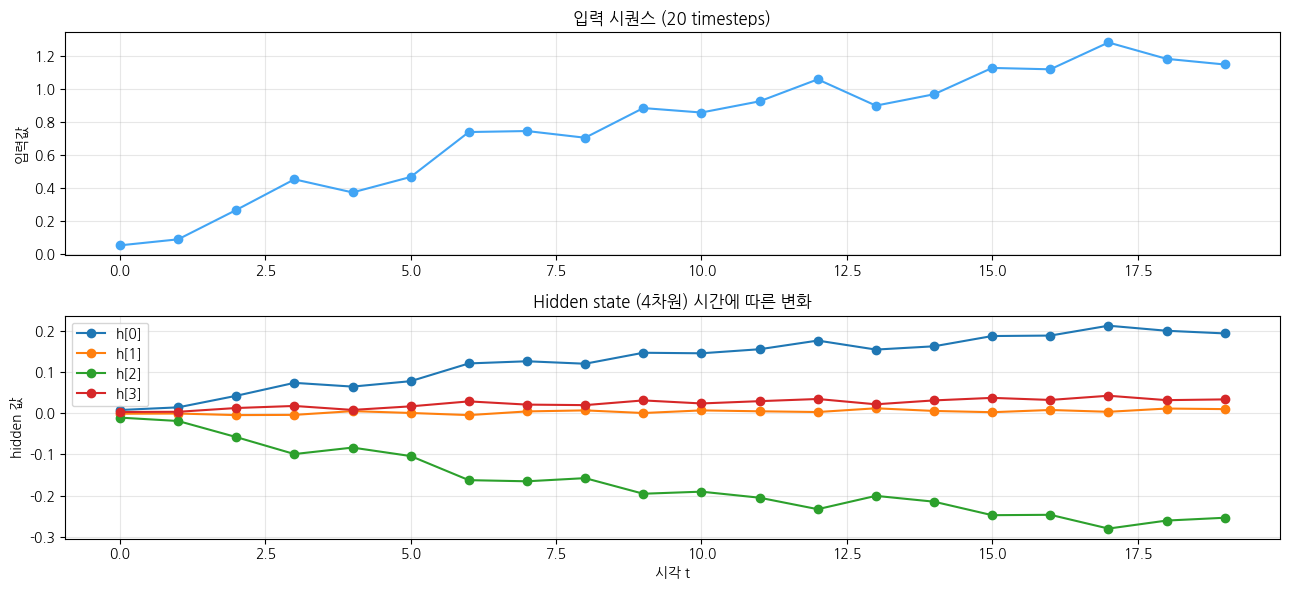


💡 hidden state가 시각이 흐를수록 입력 패턴에 반응해 변화합니다.
   (단, 가중치를 학습 안 한 랜덤 상태라 패턴은 의미없음)


In [10]:
def rnn_forward_full(x_seq, W_xh, W_hh, b):
    """시퀀스 전체에 RNN 적용 — for문으로 시각마다 cell_step 호출."""
    seq_len, input_size = x_seq.shape
    hidden_size = W_hh.shape[0]

    h = torch.zeros(hidden_size)         # 초기 hidden state = 0
    all_h = []

    for t in range(seq_len):
        h = rnn_cell_step(x_seq[t], h, W_xh, W_hh, b)
        all_h.append(h)

    return torch.stack(all_h)             # (seq_len, hidden_size)


# 첫 학습 샘플로 시퀀스 forward 해보기
x_sample = X_train_t[0]                   # (20, 1)
all_hidden = rnn_forward_full(x_sample, W_xh, W_hh, b)
print(f"입력 시퀀스 길이: {x_sample.shape[0]}")
print(f"출력 hidden states: {all_hidden.shape}  (각 시각마다의 hidden state)")

# hidden state가 시각이 흐르며 어떻게 바뀌는지 시각화
fig, axes = plt.subplots(2, 1, figsize=(13, 6))

# 위: 입력 신호
axes[0].plot(x_sample.numpy().flatten(), "o-", color="#42a5f5")
axes[0].set_title("입력 시퀀스 (20 timesteps)")
axes[0].set_ylabel("입력값"); axes[0].grid(alpha=0.3)

# 아래: 4개 hidden state 채널의 시간 변화
for i in range(hidden_size):
    axes[1].plot(all_hidden[:, i].numpy(), "o-", label=f"h[{i}]", lw=1.5)
axes[1].set_title(f"Hidden state ({hidden_size}차원) 시간에 따른 변화")
axes[1].set_xlabel("시각 t"); axes[1].set_ylabel("hidden 값")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print("\n💡 hidden state가 시각이 흐를수록 입력 패턴에 반응해 변화합니다.")
print("   (단, 가중치를 학습 안 한 랜덤 상태라 패턴은 의미없음)")

---
# 5️⃣ PyTorch nn.RNN — 한 줄로 끝!

직접 짠 것의 의미를 알았으니, 이제 **PyTorch가 제공하는 효율적인 구현** 을 씁니다.

```python
nn.RNN(input_size, hidden_size, batch_first=True)
```

내부적으로 위에서 짠 것과 똑같은 일을 하지만:
- ✅ GPU 가속
- ✅ 배치 처리 (여러 시퀀스 한꺼번에)
- ✅ 자동 미분으로 학습 가능

> 💡 **`batch_first=True`** : 입력 형태를 `(배치, 시간, feature)` 로 통일.
> False (기본값) 는 `(시간, 배치, feature)` 라 헷갈려서 보통 True 권장.

## 5.1 학습용 모델 클래스 정의


In [11]:
class SimpleRNN(nn.Module):
    """RNN 한 층 + 마지막 hidden state로 다음 값 예측."""

    def __init__(self, input_size=1, hidden_size=32, output_size=1):
        super().__init__()
        # RNN layer
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True,             # 입력 형태: (배치, 시간, feature)
        )
        # 마지막 hidden state → 출력 1개로 매핑
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        # RNN 출력: out=(batch, seq_len, hidden_size), h_n=(1, batch, hidden_size)
        out, h_n = self.rnn(x)

        # 마지막 시각의 hidden state만 사용 (= h_n)
        last_hidden = out[:, -1, :]       # (batch, hidden_size)

        # 다음 값 예측
        return self.fc(last_hidden)       # (batch, 1)


# 모델 생성
model = SimpleRNN(input_size=1, hidden_size=32, output_size=1).to(device)
print(model)

# 파라미터 수
n_params = sum(p.numel() for p in model.parameters())
print(f"\n전체 파라미터 수: {n_params:,}")
print(f"   (RNN: 입력→hidden + hidden→hidden + 편향")
print(f"    + Linear: hidden→1 + 편향)")

SimpleRNN(
  (rnn): RNN(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

전체 파라미터 수: 1,153
   (RNN: 입력→hidden + hidden→hidden + 편향
    + Linear: hidden→1 + 편향)


## 5.2 학습 — MSE loss + Adam optimizer


In [12]:
# 텐서를 device로
X_train_t = X_train_t.to(device); y_train_t = y_train_t.to(device)
X_test_t  = X_test_t.to(device);  y_test_t  = y_test_t.to(device)

# 학습 설정
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# 학습 루프
n_epochs = 30
batch_size = 32
losses_train, losses_test = [], []

for epoch in range(n_epochs):
    model.train()
    # 미니배치 학습
    perm = torch.randperm(len(X_train_t))
    epoch_loss = 0.0
    for i in range(0, len(X_train_t), batch_size):
        idx = perm[i:i+batch_size]
        Xb, yb = X_train_t[idx], y_train_t[idx]

        optimizer.zero_grad()
        pred = model(Xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(idx)

    train_loss = epoch_loss / len(X_train_t)

    # 평가
    model.eval()
    with torch.no_grad():
        test_pred = model(X_test_t)
        test_loss = criterion(test_pred, y_test_t).item()

    losses_train.append(train_loss)
    losses_test.append(test_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:>2}/{n_epochs}  train_loss={train_loss:.4f}  "
              f"test_loss={test_loss:.4f}")

print("\n✅ 학습 완료!")

Epoch  5/30  train_loss=0.0174  test_loss=0.0207
Epoch 10/30  train_loss=0.0177  test_loss=0.0195
Epoch 15/30  train_loss=0.0164  test_loss=0.0148
Epoch 20/30  train_loss=0.0167  test_loss=0.0153
Epoch 25/30  train_loss=0.0162  test_loss=0.0154
Epoch 30/30  train_loss=0.0151  test_loss=0.0140

✅ 학습 완료!


## 5.3 학습 그래프 + 예측 결과 시각화 ⭐


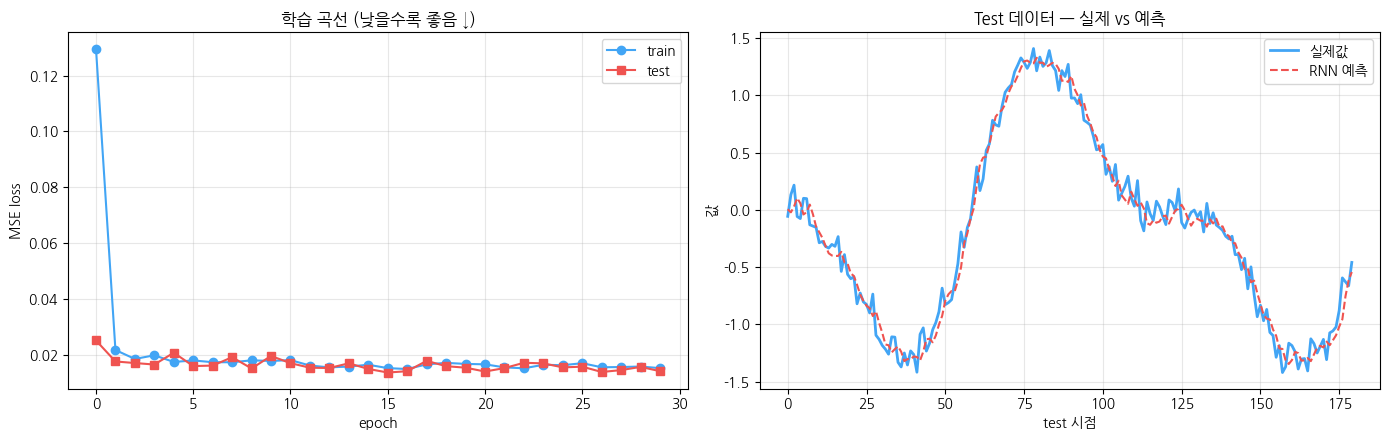

📊 Test RMSE: 0.1185

💡 빨간 점선이 파란 실선을 잘 따라가면 학습 성공!
   사인파 패턴을 RNN이 학습한 거예요 — 앞 20개 보고 다음 1개 맞추기.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# 왼쪽: loss 곡선
axes[0].plot(losses_train, "o-", label="train", color="#42a5f5")
axes[0].plot(losses_test, "s-", label="test", color="#ef5350")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("MSE loss")
axes[0].set_title("학습 곡선 (낮을수록 좋음 ↓)")
axes[0].legend(); axes[0].grid(alpha=0.3)

# 오른쪽: 학습 후 test set 예측 vs 실제값
model.eval()
with torch.no_grad():
    test_pred = model(X_test_t).cpu().numpy().flatten()
y_test_np = y_test_t.cpu().numpy().flatten()

axes[1].plot(y_test_np, label="실제값", color="#42a5f5", lw=2)
axes[1].plot(test_pred, label="RNN 예측", color="#ef5350", lw=1.5, ls="--")
axes[1].set_xlabel("test 시점"); axes[1].set_ylabel("값")
axes[1].set_title("Test 데이터 — 실제 vs 예측")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# RMSE 계산
rmse = np.sqrt(((test_pred - y_test_np)**2).mean())
print(f"📊 Test RMSE: {rmse:.4f}")
print(f"\n💡 빨간 점선이 파란 실선을 잘 따라가면 학습 성공!")
print(f"   사인파 패턴을 RNN이 학습한 거예요 — 앞 20개 보고 다음 1개 맞추기.")

---
# 6️⃣ 🎯 미션 2: 예측 오차 분석 함수 ✏️

학습이 잘 됐다는 건 알았는데, 어떤 시점이 어렵고 어떤 시점이 쉬운지 분석해봅시다.
이는 모델 디버깅의 핵심 기술!

## 6.1 [실무 시나리오]

```
"전체 RMSE는 0.15인데, 어떤 시점에서 더 틀렸나?
신호가 급격히 변하는 부분이 어려운 건 아닐까?"
```

각 시점별 오차를 계산하고 평균/최대 오차 시점을 찾는 함수를 만듭니다.

> **⏰ 5분 도전!** 빈칸 5개. numpy 기본 연산만 알면 풀 수 있어요.


In [14]:
# 🎯 미션 2: 시점별 오차 분석 함수 빈칸 채우기

def analyze_predictions(y_true, y_pred):
    """
    예측 결과의 시점별 오차 분석.

    인자:
        y_true : (N,) 실제값
        y_pred : (N,) 예측값
    반환:
        dict — 분석 결과
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # ── Step 1: 절대 오차 (각 시점별) ──
    # 💡 힌트: |실제값 - 예측값| → np.abs() 사용
    abs_errors = np.abs(y_true - y_pred)            # ✏️ abs

    # ── Step 2: 제곱 오차 ──
    # 💡 힌트: 오차의 제곱 → ** 2
    sq_errors = (y_true - y_pred) ** 2             # ✏️ ** 2 (제곱 연산자)

    # ── Step 3: RMSE (Root Mean Squared Error) ──
    # 💡 힌트: 제곱 오차 평균 → 제곱근
    rmse = np.sqrt(sq_errors.mean())                  # ✏️ mean

    # ── Step 4: 평균 절대 오차 (MAE) ──
    mae = abs_errors.mean()

    # ── Step 5: 가장 크게 틀린 시점 ──
    # 💡 힌트: 절대 오차의 최댓값 인덱스 → np.argmax()
    worst_idx = np.argmax(abs_errors)                   # ✏️ argmax

    # ── Step 6: 정확도 분류 — 임계값 0.2 이내면 "정확" ──
    # 💡 힌트: abs_errors가 0.2 이하인 비율
    accuracy = (abs_errors < 0.2).mean()             # ✏️ 0.2 (임계값)

    return {
        "rmse": rmse,
        "mae": mae,
        "worst_idx": int(worst_idx),
        "worst_error": float(abs_errors[worst_idx]),
        "accuracy_within_0.2": float(accuracy),
        "abs_errors": abs_errors,
    }


print("✏️ 빈칸 다 채우셨나요? 다음 검증 셀로 가보세요.")

✏️ 빈칸 다 채우셨나요? 다음 검증 셀로 가보세요.


<details>
<summary>🔑 정답 보기 (먼저 직접 풀어보세요!)</summary>

```python
abs_errors = np.abs(y_true - y_pred)
sq_errors = (y_true - y_pred) ** 2
rmse = np.sqrt(sq_errors.mean())
worst_idx = np.argmax(abs_errors)
accuracy = (abs_errors < 0.2).mean()
```

**핵심 패턴**:
- `np.abs(x)` : 원소별 절댓값
- `** 2` : 제곱 (제곱근은 `np.sqrt`)
- `np.argmax(arr)` : 최댓값 인덱스
- `(condition).mean()` : True/False 배열의 평균 = True 비율

</details>

## 6.2 미션 2 검증 — 위 학습된 모델 결과 분석


📊 예측 결과 분석
--------------------------------------------------
  RMSE                 : 0.1185
  MAE (평균 절대오차)   : 0.0974
  가장 틀린 시점       : index 176 (오차 0.3625)
  ±0.2 이내 정확도     : 92.8%


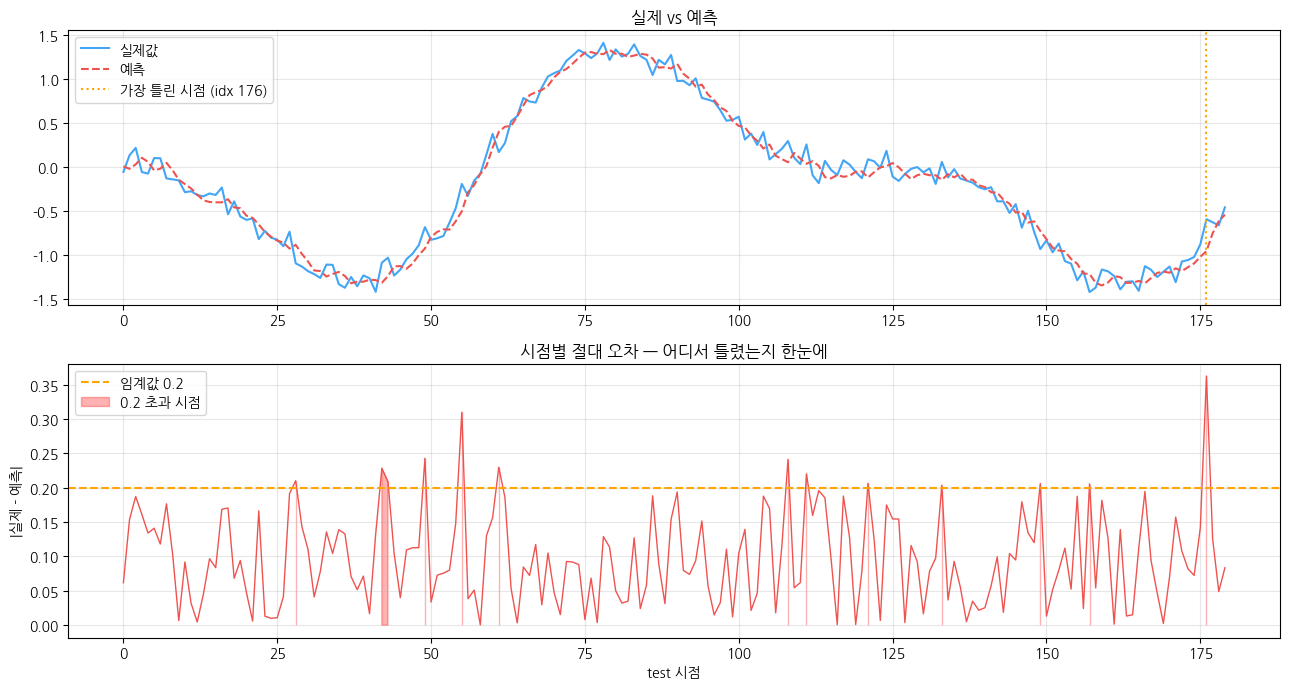


🎉 미션 2 성공! analyze_predictions가 잘 동작합니다.
   RMSE 0.119 — 학습이 잘 됐다는 뜻!

💡 인사이트: 신호가 급변하는 시점에서 오차가 큰 경향 — 이게 RNN의 한계 중 하나.


In [15]:
# 🧪 미션 2 검증

analysis = analyze_predictions(y_test_np, test_pred)

print("📊 예측 결과 분석")
print("-" * 50)
print(f"  RMSE                 : {analysis['rmse']:.4f}")
print(f"  MAE (평균 절대오차)   : {analysis['mae']:.4f}")
print(f"  가장 틀린 시점       : index {analysis['worst_idx']} (오차 {analysis['worst_error']:.4f})")
print(f"  ±0.2 이내 정확도     : {analysis['accuracy_within_0.2']*100:.1f}%")

# 시점별 오차 시각화
fig, axes = plt.subplots(2, 1, figsize=(13, 7))

# 위: 실제 vs 예측
axes[0].plot(y_test_np, label="실제값", color="#42a5f5")
axes[0].plot(test_pred, label="예측", color="#ef5350", ls="--")
axes[0].axvline(analysis["worst_idx"], color="orange", ls=":",
                label=f"가장 틀린 시점 (idx {analysis['worst_idx']})")
axes[0].set_title("실제 vs 예측")
axes[0].legend(); axes[0].grid(alpha=0.3)

# 아래: 시점별 절대 오차
axes[1].plot(analysis["abs_errors"], color="#ef5350", lw=1)
axes[1].axhline(0.2, color="orange", ls="--", label="임계값 0.2")
axes[1].fill_between(range(len(analysis["abs_errors"])),
                     0, analysis["abs_errors"],
                     where=(analysis["abs_errors"] > 0.2),
                     color="red", alpha=0.3, label="0.2 초과 시점")
axes[1].set_xlabel("test 시점"); axes[1].set_ylabel("|실제 - 예측|")
axes[1].set_title("시점별 절대 오차 — 어디서 틀렸는지 한눈에")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

if analysis["rmse"] < 0.5:
    print("\n🎉 미션 2 성공! analyze_predictions가 잘 동작합니다.")
    print(f"   RMSE {analysis['rmse']:.3f} — 학습이 잘 됐다는 뜻!")
else:
    print("\n⚠️ RMSE가 큽니다. 학습이 부족했거나 빈칸을 다시 점검하세요.")

print("\n💡 인사이트: 신호가 급변하는 시점에서 오차가 큰 경향 — 이게 RNN의 한계 중 하나.")

---
# 7️⃣ RNN의 한계 — 다음 시간 LSTM 예고

학습이 잘 됐죠? 근데 시퀀스가 길어지면 문제가 생겨요.

## 7.1 [비유로 이해] 메모장 한 페이지의 한계

메모장에 매 페이지마다 새 메모를 씁니다. 페이지가 100장이 되면 — 1페이지 메모는 다 잊어버려요.

```
1페이지: "주인공 이름은 김철수"
...
50페이지: "...." (1페이지 내용 거의 잊음)
100페이지: "주인공 이름이 뭐였더라?" ← 1페이지 정보 거의 잃음
```

이게 **Vanishing Gradient (기울기 소실)** 문제예요.

수학적으로: tanh의 미분 값은 항상 1 이하라서, 시간이 지나며 **0.9 × 0.9 × 0.9 × ... = 거의 0** 으로 수렴.
"기억"이 시간 지날수록 희석됩니다.

## 7.2 [그림으로 보기] 시퀀스 길이별 학습 어려움


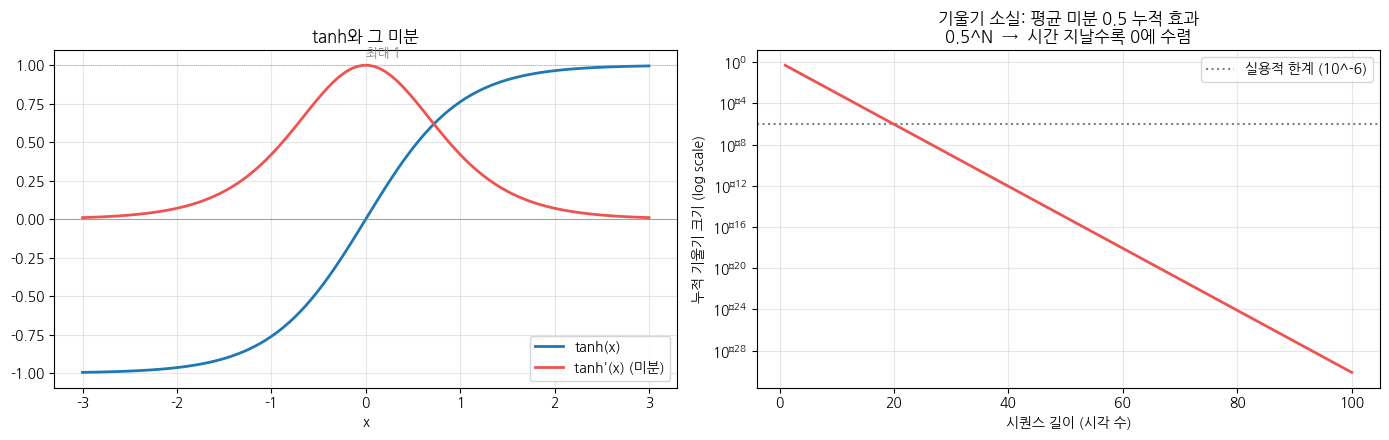

💡 50 시각만 지나도 누적 기울기가 10^-15 수준 → 학습이 거의 안 됨
   이게 RNN이 '긴 시퀀스를 학습 못 하는' 결정적 이유입니다.

   → 다음 노트북에서 다룰 LSTM이 이 문제를 해결합니다!


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import logging
logging.getLogger('matplotlib.mathtext').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

# ───────────────────────────────────────────────
# 폰트 설정 (Colab/Jupyter 첫 셀에 한 번)
# ───────────────────────────────────────────────
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['mathtext.fontset'] = 'dejavusans'

# ───────────────────────────────────────────────
# 🖼️ tanh 미분의 영향 — 기울기 소실
# ───────────────────────────────────────────────
xs = np.linspace(-3, 3, 100)
tanh_grad = 1 - np.tanh(xs)**2

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# 왼쪽: tanh와 미분
axes[0].plot(xs, np.tanh(xs), label="tanh(x)", lw=2)
axes[0].plot(xs, tanh_grad, label="tanh'(x) (미분)", lw=2, color="#ef5350")
axes[0].axhline(0, color="gray", lw=0.5)
axes[0].axhline(1, color="gray", lw=0.5, ls=":")
axes[0].set_xlabel("x")
axes[0].set_title("tanh와 그 미분")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].text(0, 1.05, "최대 1", fontsize=9, color="gray")

# 오른쪽: 누적 기울기 소실
seq_lens = np.arange(1, 101)
avg_grad = 0.5
cumulative_grad = avg_grad ** seq_lens

axes[1].semilogy(seq_lens, cumulative_grad, lw=2, color="#ef5350")
axes[1].axhline(1e-6, color="gray", ls=":", label="실용적 한계 (10^-6)")
axes[1].set_xlabel("시퀀스 길이 (시각 수)")
axes[1].set_ylabel("누적 기울기 크기 (log scale)")
axes[1].set_title("기울기 소실: 평균 미분 0.5 누적 효과\n"
                  "0.5^N  →  시간 지날수록 0에 수렴")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 50 시각만 지나도 누적 기울기가 10^-15 수준 → 학습이 거의 안 됨")
print("   이게 RNN이 '긴 시퀀스를 학습 못 하는' 결정적 이유입니다.")
print("\n   → 다음 노트북에서 다룰 LSTM이 이 문제를 해결합니다!")

---
# 8️⃣ 💪 도전 과제

## 도전 1: hidden_size 변화 효과

`hidden_size`를 8, 32, 128로 바꿔 학습하고 RMSE 비교.

```python
for hs in [8, 32, 128]:
    m = SimpleRNN(input_size=1, hidden_size=hs).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=0.005)
    # ... 학습 루프 (위 코드 재사용) ...
    print(f"hidden_size={hs}: 파라미터 {sum(p.numel() for p in m.parameters())}, RMSE=...")
```

## 도전 2: 더 긴 윈도우 vs 짧은 윈도우

```python
for w in [5, 20, 50]:
    Xtr, ytr = make_sequences(train_signal, w)
    # ... 학습 ...
    print(f"window={w}: ...")
```

> 💡 윈도우 너무 짧으면 → 정보 부족, 너무 길면 → vanishing gradient!

## 도전 3: 다중 step 미래 예측 (autoregressive)

지금은 다음 1 step만 예측. **다음 50 step 연속 예측**은 어떨까?

```python
def predict_future(model, seed_seq, n_steps):
    """seed로 시작해 n_steps 미래를 자기 출력으로 이어가며 예측"""
    model.eval()
    cur = list(seed_seq)
    preds = []
    for _ in range(n_steps):
        x = torch.FloatTensor(cur[-WINDOW:]).reshape(1, WINDOW, 1).to(device)
        with torch.no_grad():
            next_val = model(x).item()
        preds.append(next_val)
        cur.append(next_val)
    return preds

future = predict_future(model, train_signal[-WINDOW:], 100)
plt.plot(future, label="100 step 미래 예측")
plt.legend(); plt.show()
```

> 예측이 점점 흐트러질 거예요 — RNN의 한계!

---

# 🎓 정리

## 한 줄 요약

> **"앞 정보를 hidden state(메모장)에 저장하면서 다음을 예측하는 신경망."**

## 오늘 만진 것들

| 무엇을 | 비유 |
|---|---|
| **Hidden state** | 책 읽으며 메모장 갱신 📝 |
| **RNN cell forward** | 매 페이지 메모 = (이번 페이지 + 직전 메모) 정리 |
| **가중치 공유** | 같은 펜으로 모든 페이지 메모 |
| **시퀀스 처리** | 한 줄씩 책 읽기 |
| **Vanishing gradient** | 100페이지 뒤엔 1페이지 잊어버림 |

## RNN의 핵심 수식 (외워두면 좋음)

```
h_t = tanh(W_xh · x_t + W_hh · h_{t-1} + b)
```

## 다음 단계 — 시리즈 흐름

| 모델 | 핵심 개선 | 비유 |
|---|---|---|
| **RNN** (오늘) | 기본 — 메모장 1개 | 한 페이지 메모장 |
| **LSTM** (다음) | 장기 기억 + 게이트 | 회의 화이트보드 + 정리 규칙 |
| **seq2seq** | 인코더 → 디코더 | 통역사 (듣기 → 말하기) |
| **Attention** | 매번 원본 참고 | 책 펴놓고 번역 |

각 단계는 이전의 한계를 풀어가는 흐름입니다. 다음 노트북에서 LSTM이 어떻게
RNN의 vanishing gradient를 해결하는지 봐요!

## 추천 자료

- **Christopher Olah's blog** — *Understanding LSTM Networks* (RNN/LSTM 그림 설명의 명작)
- **PyTorch 공식 튜토리얼**: `Sequence Models and Long-Short Term Memory Networks`
- **3Blue1Brown** YouTube — RNN/LSTM 시각 설명

---

> 🎉 **수고하셨습니다!** RNN의 본질 — "기억을 가지고 시퀀스를 처리하는 신경망" — 을 코드로 직접 만져봤습니다.
